In [46]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_voyageai import VoyageAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
import os

In [47]:
load_dotenv()

True

In [48]:
llm = ChatOpenAI(
    model="openai/gpt-oss-20b",
    base_url="https://api.groq.com/openai/v1",
    temperature=0,
    api_key=os.getenv('GROQ_API_KEY')
)

In [49]:
loader = PyPDFLoader("paper.pdf")
docs = loader.load()
len(docs)
docs

[Document(metadata={'producer': 'PyPDF', 'creator': 'Google', 'creationdate': '', 'title': 'Quick Start Guide to Google AI', 'source': 'paper.pdf', 'total_pages': 16, 'page': 0, 'page_label': '1'}, page_content='Helpful Tips for using \nGemini  at work\nWith ready-to-use prompts'),
 Document(metadata={'producer': 'PyPDF', 'creator': 'Google', 'creationdate': '', 'title': 'Quick Start Guide to Google AI', 'source': 'paper.pdf', 'total_pages': 16, 'page': 1, 'page_label': '2'}, page_content='Prompting Best Practices \nLearn tips for writing clear, effective prompts that maximize your \nlearning and task completion.\nGemini\nDiscover how the latest Gemini features - including image generation, \nDeep Research, and Guided Learning - can elevate and support \nyour work.\nNotebookLM\nUse NotebookLM to supercharge your research, summarize \ninformation from multiple sources, establish a central team knowledge \nhub, and create custom audio and video overviews.\nGemini in Workspace\nExplore ho

In [50]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)
len(chunks)
chunks

[Document(metadata={'producer': 'PyPDF', 'creator': 'Google', 'creationdate': '', 'title': 'Quick Start Guide to Google AI', 'source': 'paper.pdf', 'total_pages': 16, 'page': 0, 'page_label': '1'}, page_content='Helpful Tips for using \nGemini  at work\nWith ready-to-use prompts'),
 Document(metadata={'producer': 'PyPDF', 'creator': 'Google', 'creationdate': '', 'title': 'Quick Start Guide to Google AI', 'source': 'paper.pdf', 'total_pages': 16, 'page': 1, 'page_label': '2'}, page_content='Prompting Best Practices \nLearn tips for writing clear, effective prompts that maximize your \nlearning and task completion.\nGemini\nDiscover how the latest Gemini features - including image generation, \nDeep Research, and Guided Learning - can elevate and support \nyour work.\nNotebookLM\nUse NotebookLM to supercharge your research, summarize \ninformation from multiple sources, establish a central team knowledge \nhub, and create custom audio and video overviews.\nGemini in Workspace\nExplore ho

In [51]:
embeddings = VoyageAIEmbeddings(
    voyage_api_key=os.getenv('VOYAGEAI_API_KEY'), model="voyage-law-2"
)
vector_store = FAISS.from_documents(chunks, embeddings)
vector_store.save_local('faiss_index')

In [52]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})
ans = retriever.invoke("What is NotebookLM?")
ans

[Document(id='2ea26f47-487c-4f50-8b45-06cb0c60671b', metadata={'producer': 'PyPDF', 'creator': 'Google', 'creationdate': '', 'title': 'Quick Start Guide to Google AI', 'source': 'paper.pdf', 'total_pages': 16, 'page': 4, 'page_label': '5'}, page_content='Understand anything with NotebookLM\nGive your \nnotebook a \nname\nShare your notebook \nwith your team so \neveryone can access \nthe information and \nget their questions \nanswered. \nUpload your sources (like pitch decks, research, project \nplans, or customer insights). \nNotebookLM will only use information from the sources you \nprovide. Think of it as an expert on your specific documents.\nVideo Overview: Turn your \nsource documents into a \nvideo of AI-narrated slides.\nAudio Overview: Turn your \nuploaded sources into in-depth \n“podcast” summaries.\nMind Map visually \nsummarize your uploaded \nsources, with related ideas \nas branching diagram.\nReports: Generate custom \ndocuments, like blog posts, based on \nyour source

In [53]:
@tool
def rag_tool(query: str) -> str:
    """
    Retrieve relevant information from the PDF document.

    Use this tool when the user asks factual or conceptual questions
    that may be answered using the stored PDF documents.

    Args:
        query: The question or search query used to retrieve PDF content.
    """

    documents = retriever.invoke(query)

    if not documents:
        return "No relevant information was found in the PDF."

    formatted_documents = []

    for index, document in enumerate(documents, start=1):
        source = document.metadata.get("source", "Unknown source")
        page = document.metadata.get("page", "Unknown page")

        formatted_documents.append(
            f"Document {index}\n"
            f"Source: {source}\n"
            f"Page: {page}\n"
            f"Content: {document.page_content}"
        )

    return "\n\n".join(formatted_documents)

In [54]:

tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)


In [55]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [56]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

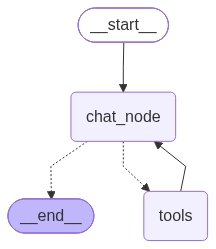

In [57]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")  
chatbot = graph.compile()

chatbot



In [58]:
result = chatbot.invoke({"messages": [HumanMessage(content="Using the pdf notes, explain about Multimodal prompting")]})

print(result["messages"][-1].content)

**Multimodal Prompting – What It Is and How to Use It**

| Source | Key Point |
|--------|-----------|
| **Document 2 – Page 14** | Multimodal prompting is listed as one of the core skills you’ll learn. |
| **Document 4 – Page 1** | Gemini’s newest features include *image generation* and *Deep Research*, which enable multimodal interactions. |
| **Document 1 – Page 7** | Ready‑to‑use prompts (many of which are multimodal) are available to jump‑start your work. |

---

### 1.  What is Multimodal Prompting?

Multimodal prompting lets you combine **different data types**—text, images, audio, video, or even structured data—into a single prompt. Instead of asking Gemini only in words, you can attach an image, upload a spreadsheet, or embed a short audio clip, and the model will process all of those inputs together to produce a richer, more context‑aware answer.

> *“Gemini … can elevate and support your work … including image generation, Deep Research, and Guided Learning.”* – Document 4, P